In [ ]:
import os
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

plt.style.use('ggplot')

In [ ]:
import os
import glob
import pandas as pd

base_dir = '../data/raw/'
patch_paths = glob.glob(os.path.join(base_dir, '**/*150x150/**/*.jpg'), recursive=True)

print("FIRST 5 IMAGE PATHS")
for i in range(min(5, len(patch_paths))):
    print(patch_paths[i])

print("\nCSV FILE HEAD")
csv_path = os.path.join(base_dir, 'CNRParkEXT.csv')
if os.path.exists(csv_path):
    try:
        df_labels = pd.read_csv(csv_path)
        display(df_labels.head())
    except Exception as e:
        print("Error reading CSV:", e)
else:
    print("CSV file not found at:", csv_path)

--- FIRST 5 IMAGE PATHS ---
../data/raw\CNR-EXT-Patches-150x150\PATCHES\OVERCAST\2015-11-16\camera1\O_2015-11-16_07.10_C01_184.jpg
../data/raw\CNR-EXT-Patches-150x150\PATCHES\OVERCAST\2015-11-16\camera1\O_2015-11-16_07.10_C01_185.jpg
../data/raw\CNR-EXT-Patches-150x150\PATCHES\OVERCAST\2015-11-16\camera1\O_2015-11-16_07.10_C01_186.jpg
../data/raw\CNR-EXT-Patches-150x150\PATCHES\OVERCAST\2015-11-16\camera1\O_2015-11-16_07.10_C01_187.jpg
../data/raw\CNR-EXT-Patches-150x150\PATCHES\OVERCAST\2015-11-16\camera1\O_2015-11-16_07.10_C01_188.jpg

--- CSV FILE HEAD ---


C:\Users\Dell\AppData\Local\Temp\ipykernel_2948\2115483985.py:17: DtypeWarning: Columns (0: camera) have mixed types. Specify dtype option on import or set low_memory=False.
  df_labels = pd.read_csv(csv_path)


,camera,datetime,day,hour,image_url,minute,month,occupancy,slot_id,weather,year,occupant_changed
0,A,20150703_0805,3,8,CNRPark/A/free/20150703_0805_1.jpg,5,7,0,1,S,2015,NaN
1,A,20150703_0810,3,8,CNRPark/A/free/20150703_0810_1.jpg,10,7,0,1,S,2015,NaN
2,A,20150703_0815,3,8,CNRPark/A/busy/20150703_0815_1.jpg,15,7,1,1,S,2015,0.0
3,A,20150703_0820,3,8,CNRPark/A/busy/20150703_0820_1.jpg,20,7,1,1,S,2015,0.0
4,A,20150703_0825,3,8,CNRPark/A/busy/20150703_0825_1.jpg,25,7,1,1,S,2015,0.0


In [ ]:
import os
import glob
import pandas as pd

base_dir = '../data/raw/'
csv_path = os.path.join(base_dir, 'CNRParkEXT.csv')

print("1. Loading CSV labels...")
df_labels = pd.read_csv(csv_path, low_memory=False)

print("2. Scanning local folders for images...")
patch_paths = glob.glob(os.path.join(base_dir, '**/*150x150/**/*.jpg'), recursive=True)
print(f"   Found {len(patch_paths)} images locally.")

print("3. Building filename mapping...")
filename_to_path = {}
for path in patch_paths:
    filename = os.path.basename(path) 
    filename_to_path[filename] = path

print("4. Merging CSV labels with local files...")
df_labels['filename'] = df_labels['image_url'].apply(lambda x: str(x).split('/')[-1])

df_labels['filepath'] = df_labels['filename'].map(filename_to_path)

df_clean = df_labels.dropna(subset=['filepath']).copy()
print(f"   Successfully matched {len(df_clean)} images!")

weather_map = {'S': 'SUNNY', 'O': 'OVERCAST', 'R': 'RAINY'}
df_clean['weather_text'] = df_clean['weather'].map(weather_map)

label_map = {0: 'FREE', 1: 'BUSY'}
df_clean['label_text'] = df_clean['occupancy'].map(label_map)

df = pd.DataFrame({
    'filepath': df_clean['filepath'],
    'weather': df_clean['weather_text'],
    'camera': df_clean['camera'].astype(str),
    'label': df_clean['occupancy'].astype(int),
    'label_text': df_clean['label_text']
})

print(f"\nFinal DataFrame Shape: {df.shape}")
display(df.head())

1. Loading CSV labels...
2. Scanning local folders for images...
   Found 157549 images locally.
3. Building filename mapping...
4. Merging CSV labels with local files...
   Successfully matched 157549 images!

Final DataFrame Shape: (157549, 5)


,filepath,weather,camera,label,label_text
0,../data/raw\CNRPark-Patches-150x150\A\free\201...,SUNNY,A,0,FREE
1,../data/raw\CNRPark-Patches-150x150\A\free\201...,SUNNY,A,0,FREE
2,../data/raw\CNRPark-Patches-150x150\A\busy\201...,SUNNY,A,1,BUSY
3,../data/raw\CNRPark-Patches-150x150\A\busy\201...,SUNNY,A,1,BUSY
4,../data/raw\CNRPark-Patches-150x150\A\busy\201...,SUNNY,A,1,BUSY


C:\Users\Dell\AppData\Local\Temp\ipykernel_2948\146135469.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='label_text', palette='Set2')


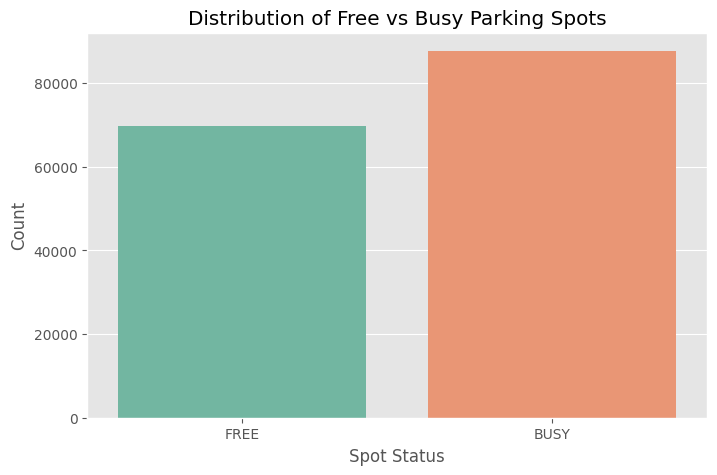

label_text
BUSY    87683
FREE    69866
Name: count, dtype: int64


In [ ]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='label_text', palette='Set2')
plt.title('Distribution of Free vs Busy Parking Spots')
plt.xlabel('Spot Status')
plt.ylabel('Count')
plt.show()

print(df['label_text'].value_counts())

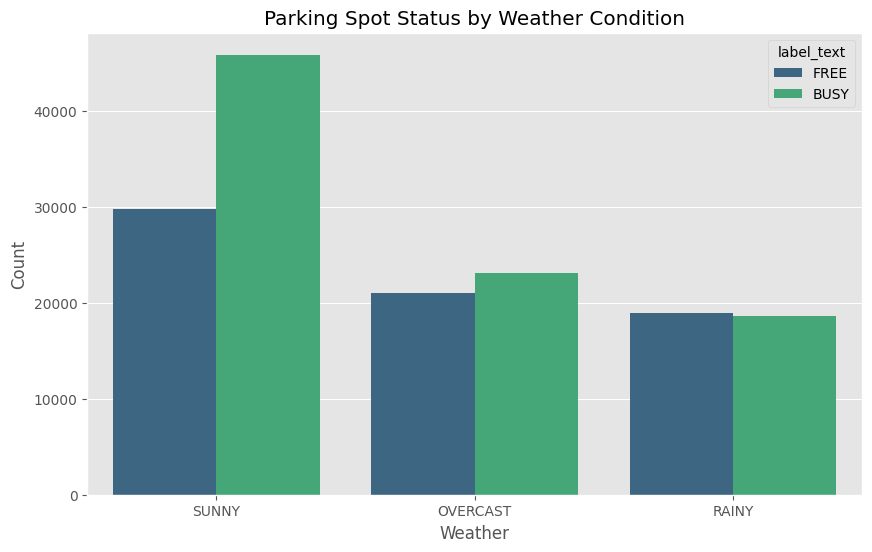

In [7]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='weather', hue='label_text', palette='viridis')
plt.title('Parking Spot Status by Weather Condition')
plt.xlabel('Weather')
plt.ylabel('Count')
plt.show()

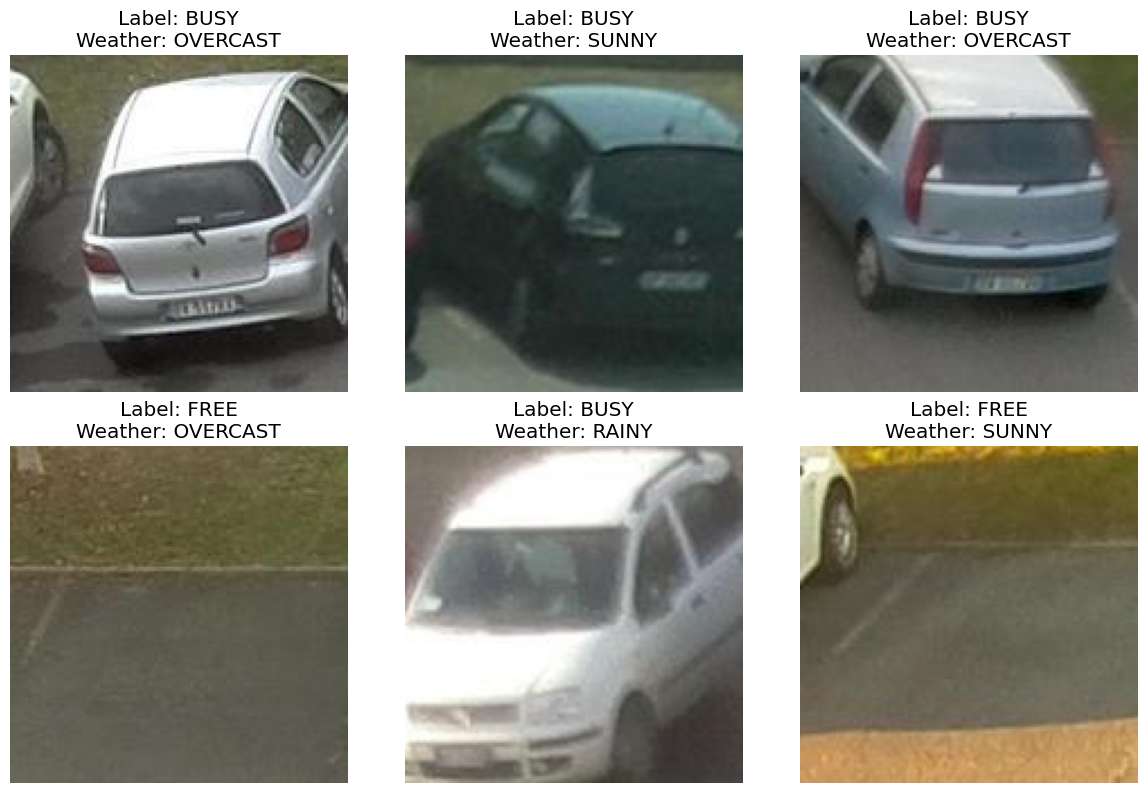

In [ ]:
sample_df = df.sample(6)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
for idx, ax in enumerate(axes.flat):
    img_path = sample_df.iloc[idx]['filepath']
    label = sample_df.iloc[idx]['label_text']
    weather = sample_df.iloc[idx]['weather']
    
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB) 
    
    ax.imshow(img)
    ax.set_title(f"Label: {label}\nWeather: {weather}")
    ax.axis('off')
plt.tight_layout()
plt.show()

In [ ]:
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

processed_dir = '../data/processed/'
if not os.path.exists(processed_dir):
    os.makedirs(processed_dir)

df.to_csv(os.path.join(processed_dir, 'parking_data.csv'), index=False)
print("Data saved successfully to processed folder!")

Data saved successfully to processed folder!
